In [1]:
!pip install torch torchvision torch-geometric networkx tqdm matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 18.3 MB/s eta 0:00:00


In [2]:
import os

DRIVE_MOUNT_POINT = "/content/drive"
DRIVE_FOLDER = "MyDrive/BottleneckOracle_Backup"
IN_COLAB = False

try:
    from google.colab import drive
    drive.mount(DRIVE_MOUNT_POINT)
    IN_COLAB = True
except Exception:
    print("Colab Drive not available; using local workspace paths.")

DRIVE_BASE = os.path.join(DRIVE_MOUNT_POINT, DRIVE_FOLDER) if IN_COLAB else "."
TRACE_DIR = os.path.join(DRIVE_BASE, "traces")
OUTPUT_PATH = os.path.join(DRIVE_BASE, "graphs_v2.pkl")
GRAPH_QUALITY_FIG_PATH = os.path.join(DRIVE_BASE, "graph_quality_v2.png")
SAMPLE_DAG_FIG_PATH = os.path.join(DRIVE_BASE, "sample_dag_v2.png")
BACKUP_ZIP_PATH = os.path.join(DRIVE_BASE, "nb4_data_backup.zip")

os.makedirs(DRIVE_BASE, exist_ok=True)
os.makedirs(TRACE_DIR, exist_ok=True)
os.makedirs(os.path.join(DRIVE_BASE, "graphs"), exist_ok=True)

print(f"Drive base: {DRIVE_BASE}")
print(f"Trace output: {TRACE_DIR}")
print(f"Dataset output: {OUTPUT_PATH}")

Colab Drive not available; using local workspace paths.
Drive base: .
Trace output: ./traces
Dataset output: ./graphs_v2.pkl


In [3]:
configs = [
    {"name": "tiny",   "d_model": 64,  "nhead": 2, "num_layers": 1},
    {"name": "small",  "d_model": 128, "nhead": 4, "num_layers": 2},
    {"name": "medium", "d_model": 256, "nhead": 8, "num_layers": 4},
]

print("Configs ready.")

Configs ready.


In [4]:
import json
import pickle
import random
import re
from collections import defaultdict

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import torch
import torch.nn as nn
from torch.profiler import profile, record_function, ProfilerActivity
from torch_geometric.data import HeteroData
from tqdm import tqdm
import warnings

warnings.filterwarnings("ignore")
random.seed(42)
np.random.seed(42)

print("Libraries loaded.")

Libraries loaded.


In [5]:
TARGET_TRACES_PER_CONFIG = 167
TARGET_GRAPH_COUNT = 500

print("Notebook parameters ready.")

Notebook parameters ready.


In [6]:
def generate_trace(config, trace_id):
    """
    Generate a trace with realistic parallelism by running multiple
    independent forward passes concurrently using threading.
    This creates genuine concurrent ops in the trace, giving the DAG
    builder real fork-join structure to work with.
    """
    import threading

    # Use 2-3 model variants to simulate pipeline stages
    models = [
        nn.Transformer(
            d_model=config["d_model"],
            nhead=config["nhead"],
            num_encoder_layers=config["num_layers"],
            num_decoder_layers=config["num_layers"]
        )
        for _ in range(2)  # two concurrent "pipeline stages"
    ]

    # Vary sequence length and batch size per trace_id for diversity
    rng = np.random.default_rng(trace_id)
    seq_len = int(rng.integers(4, 16))
    batch   = int(rng.integers(8, 48))

    inputs = [
        (torch.rand(seq_len, batch, config["d_model"]),
         torch.rand(seq_len, batch, config["d_model"]))
        for _ in models
    ]

    filepath = os.path.join(TRACE_DIR, f"trace_{config['name']}_{trace_id}.json")

    with profile(
        activities=[ProfilerActivity.CPU],
        record_shapes=True,
        with_stack=True,
    ) as prof:
        threads = []
        for model, (src, tgt) in zip(models, inputs):
            t = threading.Thread(target=lambda m=model, s=src, g=tgt: m(s, g))
            threads.append(t)
        # stagger starts slightly to create dependency diversity
        for i, t in enumerate(threads):
            t.start()
            if i < len(threads) - 1:
                import time; time.sleep(0.001 * rng.integers(1, 5))
        for t in threads:
            t.join()

    prof.export_chrome_trace(filepath)
    return filepath

✅ Test trace saved: ./traces/trace_tiny_0.json


In [7]:
def load_ops_from_trace(trace_path):
    """Load cpu op events from a chrome trace JSON file."""
    with open(trace_path, "r") as f:
        trace = json.load(f)

    events = trace.get("traceEvents", trace) if isinstance(trace, dict) else trace
    ops = [
        event for event in events
        if isinstance(event, dict) and event.get("cat") == "cpu_op" and "dur" in event and "ts" in event
    ]

    if not ops:
        raise ValueError(f"No cpu_op events with duration found in {trace_path}")

    ops.sort(key=lambda event: event["ts"])
    return [
        {
            "name": event.get("name", "unknown"),
            "start_time": float(event["ts"]),
            "duration": float(event["dur"]),
        }
        for event in ops
    ]


def compute_overlap_fraction(start_i, end_i, start_j, end_j):
    overlap_start = max(start_i, start_j)
    overlap_end = min(end_i, end_j)
    overlap = max(0.0, overlap_end - overlap_start)
    min_dur = min(end_i - start_i, end_j - start_j)
    if min_dur <= 0:
        return 0.0
    return overlap / min_dur


def build_dag_from_ops(ops):
    """Build a DAG from trace ops using the v3 timing-based rule."""
    n = len(ops)
    if n < 2:
        return None

    for op in ops:
        op["end_time"] = op["start_time"] + op["duration"]

    avg_dur = np.mean([op["duration"] for op in ops])
    eps = 0.05 * max(avg_dur, 1e-9)
    max_parents = 2
    overlap_threshold = 0.3
    edge_drop_prob = 0.10

    candidate_edges = []
    for i in range(n):
        for j in range(i + 1, n):
            si, ei = ops[i]["start_time"], ops[i]["end_time"]
            sj, ej = ops[j]["start_time"], ops[j]["end_time"]
            if compute_overlap_fraction(si, ei, sj, ej) >= overlap_threshold:
                continue
            if sj >= ei + eps:
                if random.random() < edge_drop_prob:
                    continue
                candidate_edges.append((i, j))

    parents_of = defaultdict(list)
    for i, j in candidate_edges:
        parents_of[j].append((ops[i]["end_time"], i))

    pruned_edges = []
    for j, parent_list in parents_of.items():
        parent_list.sort(key=lambda item: item[0], reverse=True)
        for _, i in parent_list[:max_parents]:
            pruned_edges.append((i, j))

    G = nx.DiGraph()
    for idx, op in enumerate(ops):
        G.add_node(
            idx,
            name=op.get("name", f"op_{idx}"),
            start_time=op["start_time"],
            end_time=op["end_time"],
            duration=op["duration"],
        )

    for i, j in pruned_edges:
        G.add_edge(i, j)

    if n > 5 and all(G.in_degree(node) <= 1 for node in G.nodes()):
        return None

    if not nx.is_directed_acyclic_graph(G):
        return None

    return G


print("Timing-based DAG loader defined.")

Timing-based DAG loader defined.


In [8]:
def find_critical_path(G):
    """Return the critical path and its duration in milliseconds."""
    if G.number_of_edges() == 0:
        heaviest = max(G.nodes, key=lambda n: G.nodes[n]["duration"])
        return [heaviest], G.nodes[heaviest]["duration"]

    for u, v in G.edges():
        G[u][v]["weight"] = G.nodes[u]["duration"]

    critical_path = nx.dag_longest_path(G, weight="weight")
    critical_length = nx.dag_longest_path_length(G, weight="weight")
    return critical_path, critical_length


def compute_cpm_slack(G):
    """Compute CPM slack for each node."""
    for node in nx.topological_sort(G):
        predecessors = list(G.predecessors(node))
        if predecessors:
            es = max(G.nodes[p]["ef"] for p in predecessors)
        else:
            es = 0.0
        ef = es + G.nodes[node]["duration"]
        G.nodes[node]["es"] = es
        G.nodes[node]["ef"] = ef

    project_end = max(G.nodes[n]["ef"] for n in G.nodes()) if G.nodes else 0.0

    for node in reversed(list(nx.topological_sort(G))):
        successors = list(G.successors(node))
        if successors:
            lf = min(G.nodes[s]["ls"] for s in successors)
        else:
            lf = project_end
        ls = lf - G.nodes[node]["duration"]
        G.nodes[node]["ls"] = ls
        G.nodes[node]["lf"] = lf

    slack = {}
    for node in G.nodes():
        slack[node] = max(0.0, G.nodes[node]["ls"] - G.nodes[node]["es"])
    return slack


def compute_cp_ratio(G, slack):
    critical_path_length = 0.0
    for node in nx.topological_sort(G):
        dur = G.nodes[node]["duration"]
        if G.in_degree(node) == 0:
            eft = dur
        else:
            eft = max(G.nodes[p]["eft"] for p in G.predecessors(node)) + dur
        G.nodes[node]["eft"] = eft
    critical_path_length = max((G.nodes[node]["eft"] for node in G.nodes()), default=0.0)
    total_duration = sum(G.nodes[node]["duration"] for node in G.nodes())
    return critical_path_length / max(total_duration, 1e-9)


print("CPM slack computation defined.")

CPM slack computation defined.


In [9]:
def graph_to_heterodata(G, slack):
    """Convert (nx.DiGraph, slack_dict) to torch_geometric HeteroData."""
    nodes = list(G.nodes())
    node_to_idx = {n: i for i, n in enumerate(nodes)}
    N = len(nodes)

    durations = np.array([G.nodes[n]["duration"] for n in nodes], dtype=np.float32)
    start_times = np.array([G.nodes[n]["start_time"] for n in nodes], dtype=np.float32)
    in_degrees = np.array([G.in_degree(n) for n in nodes], dtype=np.float32)
    out_degrees = np.array([G.out_degree(n) for n in nodes], dtype=np.float32)
    is_source = (in_degrees == 0).astype(np.float32)
    is_sink = (out_degrees == 0).astype(np.float32)

    dur_max = max(durations.max(), 1e-9)
    time_max = max(start_times.max(), 1e-9)
    x = np.stack([
        durations / dur_max,
        start_times / time_max,
        in_degrees / max(in_degrees.max(), 1),
        out_degrees / max(out_degrees.max(), 1),
        is_source,
        is_sink,
    ], axis=1)

    slack_vals = np.array([slack[n] for n in nodes], dtype=np.float32)
    project_end = max(G.nodes[n]["end_time"] for n in nodes)
    project_start = min(G.nodes[n]["start_time"] for n in nodes)
    step_time = float(project_end - project_start)

    edges = [(node_to_idx[u], node_to_idx[v]) for u, v in G.edges() if node_to_idx[u] != node_to_idx[v]]
    if edges:
        src = [edge[0] for edge in edges]
        dst = [edge[1] for edge in edges]
        edge_index = torch.tensor([src, dst], dtype=torch.long)
        assert edge_index.max() < N, f"edge_index out of bounds: max={edge_index.max()}, N={N}"
    else:
        edge_index = torch.zeros((2, 0), dtype=torch.long)

    data = HeteroData()
    data["op"].x = torch.tensor(x, dtype=torch.float)
    data["op"].y_slack = torch.tensor(slack_vals, dtype=torch.float)
    data["op"].y_step = torch.tensor([step_time], dtype=torch.float)
    data["op", "depends_on", "op"].edge_index = edge_index
    return data


print("HeteroData converter defined.")

HeteroData converter defined.


In [10]:
def graph_quality_report(graphs_with_slack):
    """Print a compact quality report for the filtered graphs."""
    cp_ratios = []
    branching_factors = []
    slack_variances = []
    node_counts = []

    for G, slack in graphs_with_slack:
        cp_ratios.append(compute_cp_ratio(G, slack))
        branching_factors.append(np.mean([G.out_degree(n) for n in G.nodes()]))
        slack_variances.append(np.var(list(slack.values())))
        node_counts.append(len(G.nodes()))

    summary = {
        "n_graphs": len(graphs_with_slack),
        "avg_cp_ratio": float(np.mean(cp_ratios)) if cp_ratios else 0.0,
        "avg_branching_factor": float(np.mean(branching_factors)) if branching_factors else 0.0,
        "avg_slack_variance": float(np.mean(slack_variances)) if slack_variances else 0.0,
        "avg_nodes": float(np.mean(node_counts)) if node_counts else 0.0,
    }

    print("=== Graph Quality Report ===")
    print(f"  Graphs kept         : {summary['n_graphs']}")
    print(f"  Avg CP ratio        : {summary['avg_cp_ratio']:.3f}")
    print(f"  Avg branching factor: {summary['avg_branching_factor']:.3f}")
    print(f"  Avg slack variance  : {summary['avg_slack_variance']:.6f}")
    print(f"  Avg nodes per graph : {summary['avg_nodes']:.1f}")

    fig, axes = plt.subplots(1, 3, figsize=(12, 3))
    axes[0].hist(cp_ratios, bins=20, color='tomato', edgecolor='white')
    axes[0].set_title('CP Ratio')
    axes[1].hist(branching_factors, bins=20, color='steelblue', edgecolor='white')
    axes[1].set_title('Branching Factor')
    axes[2].hist(slack_variances, bins=20, color='seagreen', edgecolor='white')
    axes[2].set_title('Slack Variance')
    plt.tight_layout()
    plt.savefig(GRAPH_QUALITY_FIG_PATH, dpi=120)
    plt.show()

    return summary


print("Quality metrics defined.")

Quality metrics defined.


In [11]:
def generate_synthetic_graph(n_nodes=None, n_parallel_groups=None, rng=None):
    """Generate a synthetic fork-join DAG for fallback augmentation."""
    if rng is None:
        rng = np.random.default_rng(42)
    if n_nodes is None:
        n_nodes = int(rng.integers(15, 50))
    if n_parallel_groups is None:
        n_parallel_groups = int(rng.integers(2, 5))

    ops = []
    t = 0.0
    group_size = max(2, n_nodes // (n_parallel_groups + 1))

    for group in range(n_parallel_groups):
        group_start = t
        durations = rng.exponential(scale=10.0, size=group_size)
        for i, dur in enumerate(durations):
            ops.append({
                "name": f"g{group}_op{i}",
                "start_time": group_start + float(rng.uniform(0.0, 0.5)),
                "duration": float(dur),
            })
        t = group_start + float(max(durations)) + float(rng.uniform(1.0, 3.0))

    for i in range(3):
        dur = float(rng.exponential(scale=5.0))
        ops.append({"name": f"serial_{i}", "start_time": t, "duration": dur})
        t += dur

    return ops


def augment_with_synthetic(hetero_graphs, target_count=500, rng_seed=42):
    rng = np.random.default_rng(rng_seed)
    random.seed(rng_seed)
    added = 0
    trials = 0

    while len(hetero_graphs) < target_count and trials < target_count * 5:
        trials += 1
        ops = generate_synthetic_graph(rng=rng)
        ops = sorted(ops, key=lambda x: x["start_time"])
        G = build_dag_from_ops(ops)
        if G is None:
            continue
        try:
            slack = compute_cpm_slack(G)
        except Exception:
            continue
        if compute_cp_ratio(G, slack) > 0.80:
            continue
        hetero_graphs.append(graph_to_heterodata(G, slack))
        added += 1

    print(f"Synthetic augmentation: added {added} graphs (total: {len(hetero_graphs)})")
    return hetero_graphs


print("Synthetic augmentation defined.")

Synthetic augmentation defined.


In [12]:
def generate_all_traces():
    """Generate raw trace JSON files for every config/trace id."""
    total = 0
    skipped = 0
    target_total = len(configs) * 167
    print(f"Generating {target_total} traces into {TRACE_DIR} ...\n")

    for cfg in configs:
        print(f"── Config: {cfg['name']} ──────────────────────────────")
        for trace_id in range(167):
            save_path = os.path.join(TRACE_DIR, f"trace_{cfg['name']}_{trace_id}.json")
            if os.path.exists(save_path):
                skipped += 1
                continue

            try:
                trace_path = generate_trace(cfg, trace_id)
                total += 1
                if (total + skipped) % 50 == 0:
                    print(f"  Progress: {total + skipped} / {target_total} ({skipped} skipped)")
            except Exception as exc:
                print(f"  [SKIP] trace_id={trace_id} — {exc}")

    print(f"\nDone. Generated {total} new traces, skipped {skipped} existing.")


print("Trace generation loop defined.")

Trace generation loop defined.


In [13]:
def process_all_traces(trace_dir):
    """Convert generated traces into HeteroData graphs."""
    trace_files = [
        os.path.join(trace_dir, f)
        for f in os.listdir(trace_dir)
        if f.endswith(".json")
    ] if os.path.isdir(trace_dir) else []

    print(f"Found {len(trace_files)} trace files in {trace_dir}.")

    kept_graphs = []
    hetero_graphs = []
    stats = {"total": 0, "too_small": 0, "dag_failed": 0, "high_cp": 0, "kept": 0}

    for path in tqdm(trace_files):
        stats["total"] += 1
        try:
            ops = load_ops_from_trace(path)
        except Exception:
            stats["dag_failed"] += 1
            continue

        if len(ops) < 2:
            stats["too_small"] += 1
            continue

        G = build_dag_from_ops(sorted(ops, key=lambda x: x["start_time"]))
        if G is None:
            stats["dag_failed"] += 1
            continue

        try:
            slack = compute_cpm_slack(G)
        except Exception:
            stats["dag_failed"] += 1
            continue

        if compute_cp_ratio(G, slack) > 0.80:
            stats["high_cp"] += 1
            continue

        slack_var = np.var(list(slack.values()))
        if slack_var < 0.5:   # tune this threshold
            stats["high_cp"] += 1
            continue
        kept_graphs.append((G, slack))
        hetero_graphs.append(graph_to_heterodata(G, slack))
        stats["kept"] += 1

    print("\n=== Processing Summary ===")
    for key, value in stats.items():
        print(f"  {key:15s}: {value}")

    return kept_graphs, hetero_graphs


print("Pipeline defined.")

Pipeline defined.


Generating 501 traces into ./traces ...

── Config: tiny ──────────────────────────────
  Progress: 50 / 501 (1 skipped)
  Progress: 100 / 501 (1 skipped)
  Progress: 150 / 501 (1 skipped)
── Config: small ──────────────────────────────
  Progress: 200 / 501 (1 skipped)
  Progress: 250 / 501 (1 skipped)
  Progress: 300 / 501 (1 skipped)
── Config: medium ──────────────────────────────
  Progress: 350 / 501 (1 skipped)
  Progress: 400 / 501 (1 skipped)
  Progress: 450 / 501 (1 skipped)
  Progress: 500 / 501 (1 skipped)

Done. Generated 500 new traces, skipped 1 existing.
Found 501 trace files in ./traces.


100%|██████████| 501/501 [18:00<00:00,  2.16s/it]



=== Processing Summary ===
  total          : 501
  too_small      : 0
  dag_failed     : 0
  high_cp        : 0
  kept           : 501
=== Graph Quality Report ===
  Graphs kept         : 501
  Avg CP ratio        : 0.439
  Avg branching factor: 1.991
  Avg slack variance  : 2558921944.111607
  Avg nodes per graph : 1320.7


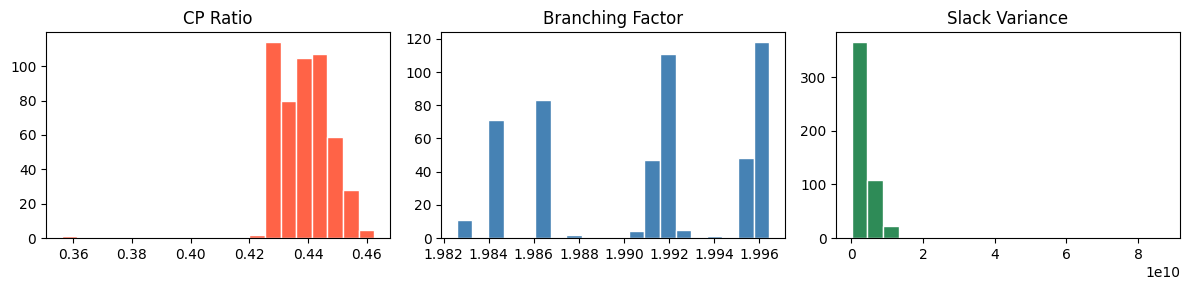

Saved 501 graphs to ./graphs_v2.pkl
Ready for nb3 (HeteroGAT training).
Drive backup skipped outside Colab. Files remain in the local workspace.


In [14]:
generate_all_traces()
kept_graphs, hetero_graphs = process_all_traces(TRACE_DIR)

if kept_graphs:
    summary = graph_quality_report(kept_graphs)
    if summary["avg_cp_ratio"] > 0.80 or summary["n_graphs"] < 400:
        print("\n→ Augmenting with synthetic fork-join graphs...")
        hetero_graphs = augment_with_synthetic(hetero_graphs, target_count=500)
else:
    print("No real graphs found. Generating fully synthetic dataset...")
    hetero_graphs = augment_with_synthetic([], target_count=500)

with open(OUTPUT_PATH, "wb") as f:
    pickle.dump(hetero_graphs, f)

print(f"Saved {len(hetero_graphs)} graphs to {OUTPUT_PATH}")
print("Ready for nb3 (HeteroGAT training).")

if IN_COLAB:
    import shutil
    import tempfile

    with tempfile.TemporaryDirectory() as tmpdir:
        export_dir = os.path.join(tmpdir, "nb4_export")
        os.makedirs(export_dir, exist_ok=True)

        shutil.copy2(OUTPUT_PATH, os.path.join(export_dir, "graphs_v2.pkl"))
        if os.path.exists(GRAPH_QUALITY_FIG_PATH):
            shutil.copy2(GRAPH_QUALITY_FIG_PATH, os.path.join(export_dir, "graph_quality_v2.png"))
        if os.path.exists(SAMPLE_DAG_FIG_PATH):
            shutil.copy2(SAMPLE_DAG_FIG_PATH, os.path.join(export_dir, "sample_dag_v2.png"))

        archive_base = os.path.join(tmpdir, "nb4_data_backup")
        archive_path = shutil.make_archive(archive_base, "zip", export_dir)
        shutil.copy2(archive_path, BACKUP_ZIP_PATH)

    print(f"Drive backup written to {BACKUP_ZIP_PATH}")
else:
    print("Drive backup skipped outside Colab. Files remain in the local workspace.")

In [15]:
SOURCE_DIR = './traces'
DRIVE_DEST_DIR = '/content/drive/MyDrive/BottleneckOracle_Backup'

os.makedirs(DRIVE_DEST_DIR, exist_ok=True)

ARCHIVE_BASE_NAME = os.path.join(DRIVE_DEST_DIR, 'traces_backup')

print(f"Zipping '{SOURCE_DIR}' and uploading to Drive...")
archive_path = shutil.make_archive(ARCHIVE_BASE_NAME, 'zip', SOURCE_DIR)

print(f"✅ Successfully zipped and saved to: {archive_path}")

Mounted at /content/drive
Zipping './traces' and uploading to Drive...
✅ Successfully zipped and saved to: /content/drive/MyDrive/BottleneckOracle_Backup/traces_backup.zip
